# 包加载和函数准备

In [1]:
import argparse
import textwrap
import logging
import os
import numpy as np
import dgl
import torch


/home/admin123/software/miniconda3/envs/GTmining_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def create_logger(branch_name):
    logger = logging.getLogger(branch_name)
    handler1 = logging.StreamHandler()
    handler2 = logging.FileHandler(filename=os.path.join('log',branch_name+'.log'))
    logger.setLevel(logging.DEBUG)
    handler1.setLevel(logging.ERROR)
    handler2.setLevel(logging.DEBUG)
    formatter = logging.Formatter("%(asctime)s %(name)s %(levelname)s %(message)s")
    handler1.setFormatter(formatter)
    handler2.setFormatter(formatter)
    logger.addHandler(handler1)
    logger.addHandler(handler2)
    return logger

class customreaddata:
    """
    A custom dataset class to read graph data from specified text files for prediction.
    Assumes the following files exist in raw_dir under a subdirectory named 'name':
    - {name}_A.txt (edge list)
    - {name}_graph_indicator.txt (which graph each node belongs to)
    - {name}_graph_labels.txt (labels for each graph) - This might be dummy for prediction
    - {name}_node_attributes.txt (features for each node)

    Parameters
    ----------
    name : str
        Name of the dataset directory and prefix for files (e.g., 'GTmining').
    raw_dir : str
        Path to the directory containing the dataset folder.
    """

    def __init__(self, name, raw_dir):
        self.name = name
        self.raw_dir = raw_dir
        self.save_dir = os.path.join(raw_dir, name) # Use raw_dir as base, create save path inside
        # os.makedirs(self.save_dir, exist_ok=True) # Ensure save directory exists for potential caching

        # Initialize attributes that will be set by process()
        self.graph_lists = []
        self.graph_labels = []
        self.max_num_node = 0
        self.num_labels = None # May not be relevant for prediction

        # Process the raw data files
        self.process()

    def _file_path(self, category):
        """Constructs the path to a specific data file."""
        return os.path.join(self.raw_dir, f"{self.name}_{category}.txt")

    @staticmethod
    def _idx_from_zero(idx_tensor):
        """Adjusts indices to be 0-based."""
        # Assuming node and graph indices in your files are 1-based.
        # If they are already 0-based, this step is unnecessary or needs adjustment.
        # Check the first few lines of your GTmining_graph_indicator.txt to confirm.
        # If they are 0-based, remove this function or make it a no-op.
        # For now, assuming 1-based as per TUDataset standard.
        min_val = np.min(idx_tensor)
        if min_val == 0:
             # If already 0-based, return as is or handle accordingly
             # This might be the case, adjust logic if needed
            #  print(f"Warning: Indices in file seem to be 0-based (min={min_val}). Proceeding assuming 0-based.")
             return idx_tensor
        else:
             # Standard 1-based to 0-based conversion
             return idx_tensor - 1 # More standard than subtracting min if known to start at 1

    def process(self):
        """
        Loads data from text files and constructs a list of DGLGraphs.
        """
        print(f"Processing custom dataset: {self.name}")

        # --- 1. Load Edge List ---
        # print(f"Loading edges from {self._file_path('A')}")
        # Load edges, assuming 1-based indexing initially
        edge_data_raw = np.genfromtxt(self._file_path("A"), delimiter=",", dtype=int)
        if edge_data_raw.ndim == 1:
            # If only one edge, reshape to (1, 2)
            edge_data_raw = edge_data_raw.reshape(1, -1)
        # Convert to 0-based indices
        edge_data_0_based = self._idx_from_zero(edge_data_raw)
        # DGL expects source and destination arrays
        src_nodes = edge_data_0_based[:, 0]
        dst_nodes = edge_data_0_based[:, 1]

        # --- 2. Load Graph Indicator (which graph each node belongs to) ---
        # print(f"Loading graph indicators from {self._file_path('graph_indicator')}")
        node_graph_ids_raw = np.loadtxt(self._file_path("graph_indicator"), dtype=int)
        # Convert graph IDs to 0-based indices
        node_graph_ids = self._idx_from_zero(node_graph_ids_raw)
        num_total_nodes_in_file = len(node_graph_ids_raw)

        # --- 3. Load Graph Labels (might be dummy) ---
        # print(f"Loading graph labels from {self._file_path('graph_labels')}")
        try:
            graph_labels_raw = np.loadtxt(self._file_path("graph_labels"), dtype=int)
            # Convert graph labels to 0-based indices if needed, though for classification
            # they often represent class IDs starting from 0 or 1. Adjust if necessary.
            # For prediction, these might just be placeholders.
            self.graph_labels = graph_labels_raw # Keep original values for now, adjust if necessary
            self.num_labels = max(self.graph_labels) + 1 if len(self.graph_labels) > 0 else 0
        except FileNotFoundError:
            print(f"Warning: Graph labels file {self._file_path('graph_labels')} not found. Using dummy labels (e.g., 0).")
            num_graphs_in_file = len(set(node_graph_ids))
            self.graph_labels = np.zeros(num_graphs_in_file, dtype=int) # Dummy labels
            self.num_labels = 1 # Or set to None if not applicable


        # --- 4. Load Node Attributes ---
        # print(f"Loading node attributes from {self._file_path('node_attributes')}")
        try:
            node_attributes = np.loadtxt(self._file_path("node_attributes"), delimiter=",")
            if node_attributes.ndim == 1:
                # If features are 1D (one feature per node), reshape to (num_nodes, 1)
                node_attributes = np.expand_dims(node_attributes, axis=1)
            # print(f"Loaded node attributes with shape: {node_attributes.shape}")
            if node_attributes.shape[0] != num_total_nodes_in_file:
                 raise ValueError(f"Number of rows in node_attributes ({node_attributes.shape[0]}) does not match number of nodes indicated by graph_indicator ({num_total_nodes_in_file}).")
        except FileNotFoundError:
            print(f"Warning: Node attributes file {self._file_path('node_attributes')} not found. Graphs will have no node features (ndata['feat'] will not be set initially).")
            node_attributes = None


        # --- 5. Create a Base Graph with All Nodes and Edges ---
        # This graph contains all nodes from all graphs, connected by the provided edges.
        num_nodes_in_base_graph = int(np.max(src_nodes)) + 1 if len(src_nodes) > 0 else 0
        # Ensure num_nodes includes any isolated nodes that might only appear in graph_indicator
        num_nodes_in_base_graph = max(num_nodes_in_base_graph, num_total_nodes_in_file)

        if num_nodes_in_base_graph == 0:
            print("Warning: No nodes or edges found in the data files.")
            self.graph_lists = []
            return

        base_graph = dgl.graph(([], []), num_nodes=num_nodes_in_base_graph)
        base_graph.add_edges(src_nodes, dst_nodes)

        # Assign node attributes to the base graph if available
        if node_attributes is not None:
            base_graph.ndata['feat'] = torch.tensor(node_attributes, dtype=torch.float32)

        # --- 6. Split the Base Graph into Individual Graphs ---
        self.graph_lists = []
        self.max_num_node = 0

        num_expected_graphs = len(set(node_graph_ids))
        print(f"Found {num_expected_graphs} graphs based on graph_indicator.")

        for graph_id in range(num_expected_graphs):
            # Find the nodes belonging to the current graph (graph_id)
            node_mask = (node_graph_ids == graph_id)
            node_indices_for_graph = np.where(node_mask)[0] # Get 0-based indices of nodes in this graph

            if len(node_indices_for_graph) == 0:
                print(f"Warning: Graph ID {graph_id} has no nodes according to graph_indicator.")
                # Create an empty graph for this ID
                g_sub = dgl.graph(([], []), num_nodes=0)
                # Add a dummy feature tensor if original had features, though shape might be tricky for 0 nodes
                # Often, empty graphs might need special handling downstream.
                # For now, just create the empty graph.
            else:
                # Extract the subgraph corresponding to these nodes
                g_sub = base_graph.subgraph(node_indices_for_graph)

                # The subgraph's nodes have new IDs (0, 1, ...). The original features are preserved based on the subgraph operation.
                # If node_attributes was loaded, 'feat' is already in g_sub.ndata.
                # Check if 'feat' exists, otherwise features were not available.
                if 'feat' not in g_sub.ndata:
                     print(f"  Graph {graph_id}: No node features available.")


            self.graph_lists.append(g_sub)

            if g_sub.num_nodes() > self.max_num_node:
                self.max_num_node = g_sub.num_nodes()

        # print(f"Successfully processed {len(self.graph_lists)} graphs.")
        # print(f"Max number of nodes in a single graph: {self.max_num_node}")


    def __getitem__(self, idx):
        """
        Gets the graph and its label at the given index.

        Parameters
        ---------
        idx : int
            The sample index.

        Returns
        -------
        dgl.DGLGraph
            The graph object, potentially with node features in `ndata['feat']`.
        torch.Tensor
            The label tensor for the graph (could be dummy for prediction).
        """
        if idx < 0 or idx >= len(self):
             raise IndexError(f"Index {idx} is out of range for dataset with {len(self)} items.")
        g = self.graph_lists[idx]
        label = torch.tensor(self.graph_labels[idx], dtype=torch.int64) if self.graph_labels is not None else torch.tensor(0, dtype=torch.int64) # Return a dummy label if not set
        return g, label

    def __len__(self):
        """
        Returns the number of graphs in the dataset.
        """
        return len(self.graph_lists)

    @property
    def num_classes(self):
        """Returns the number of classes (uses num_labels)."""
        return int(self.num_labels) if self.num_labels is not None else 0 # Return 0 if not set

# 主函数

In [3]:
# 参数设置
device = "cuda:0"
args = argparse.Namespace(batch_size=256, learningrate=1e-4, dropout=0.1, branch='mf', labels_num=10, use_cbam=True, family_fold_type='GTA', fold_num=1)
print(textwrap.fill(str(args), width=150))
# 训练日志
logger = create_logger(args.branch)

# 载入/设置参数
epoch_num = 100
batch_size = args.batch_size
learningrate = args.learningrate
dropout = args.dropout
labels_num = args.labels_num

# 加载数据
print("{:=^100}".format('加载数据'))
dataset_train = customreaddata(name="GTmining", raw_dir=f'./data/{args.family_fold_type}_alldata/fold{args.fold_num}/train/')
train_dataloader = dgl.dataloading.GraphDataLoader(dataset=dataset_train, batch_size=args.batch_size, drop_last=False, shuffle=True, num_workers=2)

valid_dataloader = customreaddata(name="GTmining", raw_dir=f'./data/{args.family_fold_type}_alldata/fold{args.fold_num}/validation/')
valid_dataloader = dgl.dataloading.GraphDataLoader(dataset=valid_dataloader, batch_size=args.batch_size, drop_last=False, shuffle=True, num_workers=2)

test_dataloader = customreaddata(name="GTmining", raw_dir=f'./data/{args.family_fold_type}_alldata/fold{args.fold_num}/test/')
test_dataloader = dgl.dataloading.GraphDataLoader(dataset=test_dataloader, batch_size=args.batch_size, drop_last=False, shuffle=False, num_workers=2)

# nova_dataloader = customreaddata(name="GTmining", raw_dir=f'./data/{args.family_fold_type}_alldata/fold{args.fold_num}/nova/')
# nova_dataloader = dgl.dataloading.GraphDataLoader(dataset=nova_dataloader, batch_size=args.batch_size, drop_last=False, shuffle=False, num_workers=2)


Namespace(batch_size=256, learningrate=0.0001, dropout=0.1, branch='mf', labels_num=10, use_cbam=True, family_fold_type='GTA', fold_num=1)
================================================加载数据================================================
Processing custom dataset: GTmining
Found 7915 graphs based on graph_indicator.
Processing custom dataset: GTmining
Found 2258 graphs based on graph_indicator.
Processing custom dataset: GTmining
Found 1316 graphs based on graph_indicator.


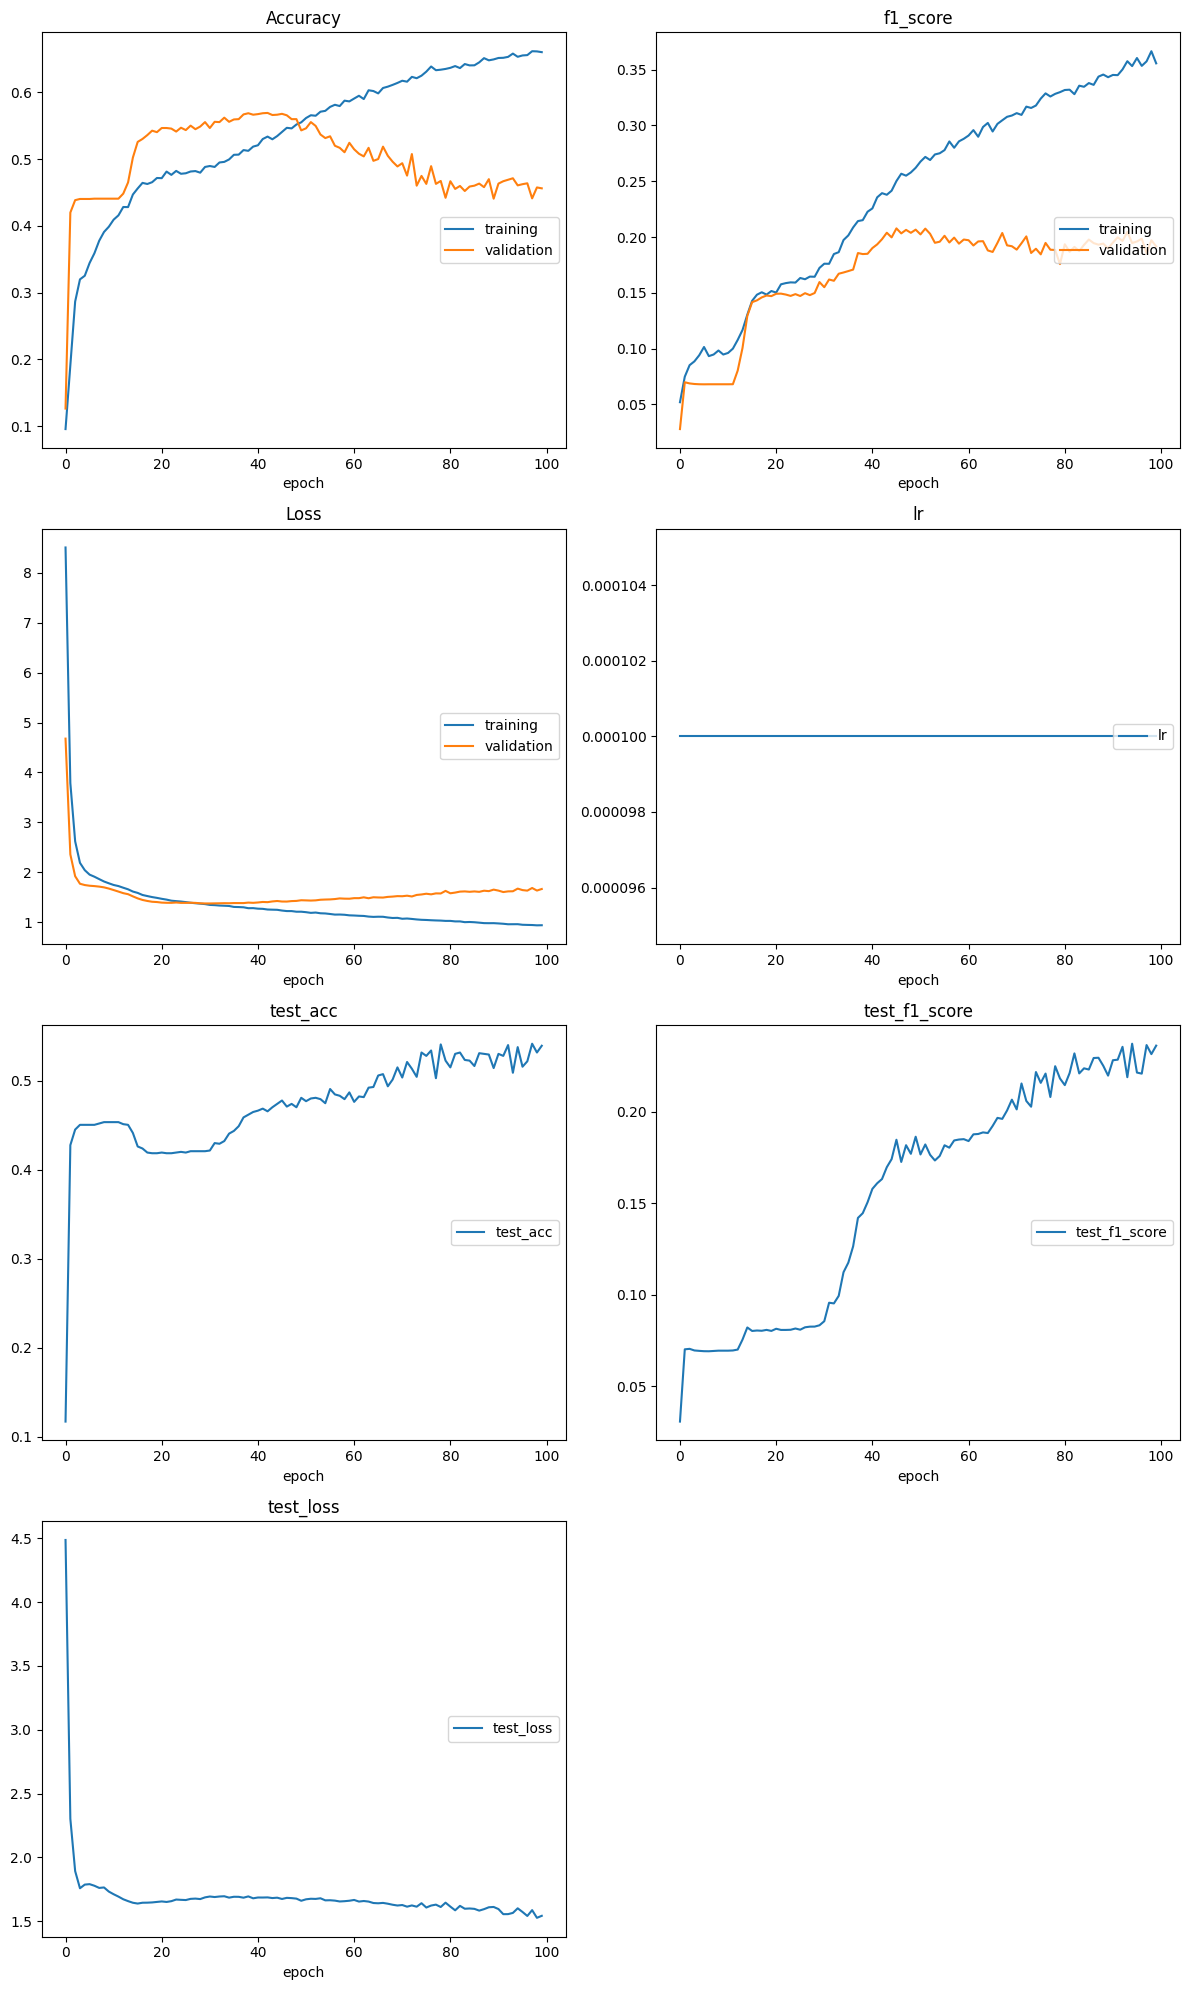

Accuracy
	training         	 (min:    0.096, max:    0.662, cur:    0.660)
	validation       	 (min:    0.126, max:    0.569, cur:    0.456)
f1_score
	training         	 (min:    0.052, max:    0.367, cur:    0.356)
	validation       	 (min:    0.028, max:    0.208, cur:    0.192)
Loss
	training         	 (min:    0.941, max:    8.504, cur:    0.943)
	validation       	 (min:    1.378, max:    4.678, cur:    1.668)
lr
	lr               	 (min:    0.000, max:    0.000, cur:    0.000)
test_acc
	test_acc         	 (min:    0.117, max:    0.542, cur:    0.540)
test_f1_score
	test_f1_score    	 (min:    0.031, max:    0.237, cur:    0.236)
test_loss
	test_loss        	 (min:    1.527, max:    4.487, cur:    1.542)


In [4]:
# # 加载autoreload扩展
# %load_ext autoreload
# # 设置自动重载等级：2表示所有模块（包括第三方/本地包）都会强制重新加载
# %autoreload 2

from model.network import SAGNetworkHierarchical
import torch.optim as optim
from transformers import get_cosine_schedule_with_warmup
import torch.nn as nn
from tqdm import tqdm
from livelossplot import PlotLosses
import torch.nn.functional as F
import pandas as pd
from sklearn.metrics import f1_score

# class FocalLoss(nn.Module):
#     """Focal Loss for handling class imbalance"""
#     def __init__(self, alpha=1, gamma=2):
#         super(FocalLoss, self).__init__()
#         self.alpha = alpha
#         self.gamma = gamma
        
#     def forward(self, inputs, targets):
#         bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
#         pt = torch.exp(-bce_loss)
#         focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
#         return focal_loss.mean()

# class FocalLoss(nn.Module):
#     def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
#         """
#         Focal Loss 实现
#         Args:
#             gamma: 聚焦参数，gamma=0 时等价于普通交叉熵损失
#             alpha: 类别权重，处理类别不平衡，None 则不使用
#             reduction: 损失聚合方式，可选 'mean'/'sum'/'none'
#         """
#         super(FocalLoss, self).__init__()
#         self.gamma = gamma
#         self.alpha = alpha
#         if alpha is not None:
#             self.alpha = torch.tensor(alpha)
#         self.reduction = reduction

#     def forward(self, logits, labels):
#         # 将 logits 转换为概率（softmax）
#         probs = F.softmax(logits, dim=1)
#         # 获取对应类别的概率
#         p_t = probs.gather(1, labels.unsqueeze(1)).squeeze(1)
#         # 计算交叉熵的基础损失
#         ce_loss = F.cross_entropy(logits, labels, reduction='none')
#         # 计算 focal 系数 (1 - p_t)^gamma
#         focal_weight = (1 - p_t) ** self.gamma

#         # 应用 alpha 权重（如果设置）
#         if self.alpha is not None:
#             alpha_t = self.alpha.to(logits.device)[labels]
#             focal_weight = alpha_t * focal_weight

#         # 计算最终的 focal loss
#         loss = focal_weight * ce_loss

#         # 按照指定方式聚合损失
#         if self.reduction == 'mean':
#             return loss.mean()
#         elif self.reduction == 'sum':
#             return loss.sum()
#         else:
#             return loss


model = SAGNetworkHierarchical(7, 32, labels_num, num_convs=1, pool_ratio=0.5, dropout=dropout, use_cbam=args.use_cbam).to(device)
optimizer = optim.Adam(model.parameters(), lr=learningrate)
# lr_scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=300, num_training_steps=epoch_num*len(train_dataloader))

# 损失函数
criterion = nn.CrossEntropyLoss()
# if args.family_fold_type == 'GTA':
#     graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
#                         'UDP-Gal': 3, 'UDP-GalNAc': 4,
#                         'UDP-Xyl': 5, 'GDP-Man': 6,
#                         'dTDP-Rha': 7, 'Other': 8}
# elif args.family_fold_type == 'GTB':
#     graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
#                         'UDP-Gal': 3, 'UDP-GalNAc': 4,
#                         'UDP-Xyl': 5, 'GDP-Man': 6, 'GDP-Fuc': 7,
#                         'dTDP-Rha': 8, 'Other': 9}
# else:
#     raise ValueError(f"Invalid family_fold_type: '{args.family_fold_type}'. Valid options are 'GTA' and 'GTB'.")
# df_cluster = pd.read_excel(f'../data/cluster/{args.family_fold_type}_alldata/dataseat_split_{args.fold_num}.xlsx')
# df_cluster = df_cluster.loc[df_cluster['Dataset']=='train']
# df_cluster.reset_index(drop=True, inplace=True)
# custom_loss_weight = []
# total_sample = df_cluster.shape[0]
# for x in graph_label_dict.keys():
#     df_x = df_cluster.loc[df_cluster['Activate']==x]
#     df_x.reset_index(drop=True, inplace=True)
#     x_sample = df_x.shape[0]
#     custom_loss_weight.append(total_sample/x_sample)

# assert len(custom_loss_weight) == args.labels_num, 'Wrong custom loss weight, please check what happen.'

# criterion = nn.CrossEntropyLoss(weight=torch.tensor(custom_loss_weight).cuda()) # 支持外部传输的损失权重
# # 使用Focal Loss处理严重不平衡
# criterion = FocalLoss(gamma=2.0)

best_fscore = 0
best_aupr = 0
best_scores = []
best_score_dict = {}
logger.info('#########'+args.branch+'###########')
logger.info('########start training###########')

liveloss = PlotLosses()  # 初始化实时绘图对象
logs = {}  # 存储当前epoch的损失数据

# 开始训练
for epoch in range(epoch_num):
    print("epoch:",epoch)
    logger.info("epoch: "+str(epoch))
    model.train()
    train_loss = 0
    print("training")
    logger.info("training")
    accum_correct = 0
    total = 0
    # for i,(graphs, labels) in tqdm(enumerate(train_dataloader)):
    # 暂时存储，方便计算准确性
    train_pred_indi = torch.tensor([], device='cuda')
    train_label_indi = torch.tensor([], device='cuda')
    for i,(graphs, labels) in enumerate(train_dataloader):
        # print("batch size:", graphs.batch_size) # 64

        # graphs = dgl.add_self_loop(graphs) # 给图添加自环（解决0入度问题）

        # print("batch size:", graphs.batch_size) # 1

        # print("batch size (加自环前):", graphs.batch_size) # 输出64
    
        # 核心修复：拆分→加自环→重新批次
        subgraphs = dgl.unbatch(graphs)  # 拆分为64张子图
        subgraphs_with_self_loop = [dgl.add_self_loop(g) for g in subgraphs]  # 每张图加自环
        graphs = dgl.batch(subgraphs_with_self_loop)  # 重新合并为批次图
        
        # print("batch size (加自环后):", graphs.batch_size) # 输出64（保留批次信息）

        for key, value in graphs.ndata.items():
            graphs.ndata[key] = value.float()
        graphs = graphs.to(device)
        labels = labels.long()
        labels = labels.to(device)
        labels = torch.squeeze(labels)
        # labels = labels.flatten()
        # if len(labels.shape)==1:
        #     labels = labels.unsqueeze(0)

        optimizer.zero_grad()
        logits = model(graphs)
        
        loss = criterion(logits,labels)
        loss.backward()
        optimizer.step()
        # lr_scheduler.step()


        # 累加计算平均loss
        train_loss+=loss.item()
        indi = torch.argmax(logits, dim=1)
        accum_correct += (indi == labels).sum().item()
        total += labels.size(0)

        train_pred_indi = torch.cat((train_pred_indi, indi), dim=0)
        train_label_indi = torch.cat((train_label_indi, labels), dim=0)

        # 记录当前批次的训练损失（实时更新）
        batch_avg_loss = train_loss / (i + 1)
        # logs['loss'] = batch_avg_loss  # 累计平均损失
        # logs['lr'] = optimizer.param_groups[0]['lr']  # 可选：记录学习率
        # logs['acc'] = accum_correct / total  # 计算并记录训练准确率
        
        # break
        
        
        # if i%15 == 14:
        # liveloss.update(logs)
        # liveloss.send()  # 刷新图表
        logger.info(f'Epoch: {epoch} / {epoch_num}, Step: {i} / {len(train_dataloader)}, Loss(batch): {batch_avg_loss}')

    train_f1_score = f1_score(train_pred_indi.cpu(), train_label_indi.cpu(), average='macro')
    logger.info(f'Train F1 Score: {train_f1_score}')

    logs['f1_score'] = train_f1_score

    logs['loss'] = batch_avg_loss  # 累计平均损失
    logs['lr'] = optimizer.param_groups[0]['lr']  # 可选：记录学习率
    logs['acc'] = accum_correct / total  # 计算并记录训练准确率


    model.eval()
    print("validating")
    logger.info("validating")
    valid_loss = 0
    pred = []
    actual = []
    valid_pred_indi = torch.tensor([], device='cuda')
    valid_label_indi = torch.tensor([], device='cuda')
    with torch.no_grad():
        accum_correct = 0
        total = 0
        for i,(graphs, labels) in tqdm(enumerate(valid_dataloader)):
            # 核心修复：拆分→加自环→重新批次
            subgraphs = dgl.unbatch(graphs)  # 拆分为64张子图
            subgraphs_with_self_loop = [dgl.add_self_loop(g) for g in subgraphs]  # 每张图加自环
            graphs = dgl.batch(subgraphs_with_self_loop)  # 重新合并为批次图
            
            # print("batch size (加自环后):", graphs.batch_size) # 输出64（保留批次信息）

            for key, value in graphs.ndata.items():
                graphs.ndata[key] = value.float()
            graphs = graphs.to(device)
            labels = labels.to(device)
            labels = torch.squeeze(labels)

            
            logits = model(graphs)
            # logits = F.sigmoid(logits)
            
            loss = criterion(logits,labels)

            # 累加计算平均loss
            valid_loss += loss.item()
            pred += logits.tolist()
            indi = torch.argmax(logits, dim=1)
            actual += labels.tolist()
            accum_correct += (indi == labels).sum().item()
            total += labels.size(0)

            valid_pred_indi = torch.cat((valid_pred_indi, indi), dim=0)
            valid_label_indi = torch.cat((valid_label_indi, labels), dim=0)

            # 记录当前批次的训练损失（实时更新）
            batch_avg_loss = valid_loss / (i + 1)
            # logs['val_loss'] = batch_avg_loss  # 累计平均损失
            # logs['val_acc'] = accum_correct / total  # 计算并记录验证准确率

            

            # if i%5 == 4:
            # liveloss.update(logs)
            # liveloss.send()  # 刷新图表
            # logger.info(f'Valid Step: {i} / {len(valid_dataloader)}, Loss(batch): {loss.item()}')
            logger.info(f'Valid Step: {i} / {len(valid_dataloader)}, Loss(batch): {batch_avg_loss}')

        logs['val_loss'] = batch_avg_loss  # 累计平均损失
        logs['val_acc'] = accum_correct / total  # 计算并记录验证准确率
        valid_f1_score = f1_score(valid_pred_indi.cpu(), valid_label_indi.cpu(), average='macro')
        logs['val_f1_score'] = valid_f1_score
        logger.info(f'Valid F1 Score: {valid_f1_score}')


        nova_loss = 0
        accum_correct = 0
        total = 0
        test_pred_indi = torch.tensor([], device='cuda')
        test_label_indi = torch.tensor([], device='cuda')
        for i,(graphs, labels) in tqdm(enumerate(test_dataloader)):
            # 核心修复：拆分→加自环→重新批次
            subgraphs = dgl.unbatch(graphs)  # 拆分为64张子图
            subgraphs_with_self_loop = [dgl.add_self_loop(g) for g in subgraphs]  # 每张图加自环
            graphs = dgl.batch(subgraphs_with_self_loop)  # 重新合并为批次图
            
            # print("batch size (加自环后):", graphs.batch_size) # 输出64（保留批次信息）

            for key, value in graphs.ndata.items():
                graphs.ndata[key] = value.float()
            graphs = graphs.to(device)
            labels = labels.to(device)
            labels = torch.squeeze(labels)

            
            logits = model(graphs)
            # logits = F.sigmoid(logits)
            
            loss = criterion(logits,labels)

            # 累加计算平均loss
            nova_loss += loss.item()
            pred += logits.tolist()
            indi = torch.argmax(logits, dim=1)
            actual += labels.tolist()
            accum_correct += (indi == labels).sum().item()
            total += labels.size(0)

            test_pred_indi = torch.cat((test_pred_indi, indi), dim=0)
            test_label_indi = torch.cat((test_label_indi, labels), dim=0)

            # 记录当前批次的训练损失（实时更新）
            batch_avg_loss = nova_loss / (i + 1)
            # logs['val_loss'] = batch_avg_loss  # 累计平均损失
            # logs['val_acc'] = accum_correct / total  # 计算并记录验证准确率

            

            # if i%5 == 4:
            # liveloss.update(logs)
            # liveloss.send()  # 刷新图表
            # logger.info(f'Valid Step: {i} / {len(valid_dataloader)}, Loss(batch): {loss.item()}')
            logger.info(f'Valid Step: {i} / {len(test_dataloader)}, Loss(batch): {batch_avg_loss}')

        test_f1_score = f1_score(test_pred_indi.cpu(), test_label_indi.cpu(), average='macro')
        logs['test_f1_score'] = test_f1_score
        logger.info(f'Test F1 Score: {test_f1_score}')
        logs['test_loss'] = batch_avg_loss  # 累计平均损失
        logs['test_acc'] = accum_correct / total  # 计算并记录测试准确率
    liveloss.update(logs)
    liveloss.send()  # 刷新图表


    # break




In [ ]:
indi = torch.argmax(logits, dim=1)
indi

In [ ]:
model.eval()
print("validating")
logger.info("validating")
valid_loss = 0
pred = []
actual = []
with torch.no_grad():
    for i,(graphs, labels) in enumerate(valid_dataloader):
        # 核心修复：拆分→加自环→重新批次
        subgraphs = dgl.unbatch(graphs)  # 拆分为64张子图
        subgraphs_with_self_loop = [dgl.add_self_loop(g) for g in subgraphs]  # 每张图加自环
        graphs = dgl.batch(subgraphs_with_self_loop)  # 重新合并为批次图
        
        # print("batch size (加自环后):", graphs.batch_size) # 输出64（保留批次信息）

        for key, value in graphs.ndata.items():
            graphs.ndata[key] = value.float()
        graphs = graphs.to(device)
        labels = labels.to(device)
        labels = torch.squeeze(labels)

        
        logits = model(graphs)
        # logits = F.sigmoid(logits)
        
        loss = criterion(logits,labels)

        # 累加计算平均loss
        valid_loss += loss.item()

        # 记录当前批次的训练损失（实时更新）
        batch_avg_loss = valid_loss / (i + 1)
        logs['loss_val'] = batch_avg_loss  # 累计平均损失

        print(f"Batch {i}: Loss={loss.item()}, Cumulative Avg Loss={batch_avg_loss}")
        


In [ ]:
indicator = torch.argmax(logits, dim=1)
indicator

In [ ]:
loss = criterion(logits,labels.flatten())
loss

In [ ]:
logits

In [ ]:
labels

In [ ]:
labels.flatten()